## Problem decyzyjny – inwestycje: mieszkania 2 pokoje

**Kryteria:**

1. Cena mieszkania [zł] – *koszt*
2. Powierzchnia [m²] – *zysk*  
3. Piętro [nr piętra] – *zysk*
4. Powierzchnia balkonu [m²] – *zysk*  
5. Cena parkingu [zł] – *koszt*

**Alternatywy (mieszkania 2‑pokojowe):**

- A1 – Heyki City  
- A2 – Floriana  
- A3 – Sedina  
- A4 – Grand Bvlwar  
- A5 – Gardenia  
- A6 – Silver Garden  

**Macierz decyzyjna:**

| Alt             | Cena [zł] | Powierzchnia [m²] | Piętro | Balkon [m²] | Cena parkingu [zł] |
|-----------------|--------------|----------------------|----------|----------------|------------------------|
| Heyki City       | 540598       | 37.72                | 4        | 8.29           | 65000                  |
| Floriana     | 500760       | 42.80                | 4        | 4.00           | 60000                  |
| Sedina       | 615489       | 38.71                | 5        | 3.55           | 65000                  |
| GrandBvlwar  | 483720       | 34.80                | 2        | 3.98           | 65000                  |
| Gardenia     | 559816       | 44.08                | 1        | 0.00           | 65000                  |
| SilverGarden | 520520       | 40.04                | 7        | 0.00           | 70000                  |

In [ ]:
import numpy as np
from pymcdm.methods import TOPSIS, SPOTIS, VIKOR, WASPAS, COMET
from pymcdm.weights.subjective import AHP, RANCOM
from pymcdm.weights import critic_weights, entropy_weights
from pymcdm.helpers import rankdata, rrankdata
from pymcdm.methods.comet_tools import MethodExpert
from pymcdm.correlations import weighted_spearman, rank_similarity_coef, wsc
from pymcdm.visuals import ranking_flows, correlation_heatmap
import matplotlib.pyplot as plt

In [ ]:


D = np.array([
    [540598, 37.72, 4, 8.29, 65000],   # A1 Heyki City
    [500760, 42.80, 4, 4.00, 60000],   # A2 Floriana
    [615489, 38.71, 5, 3.55, 65000],   # A3 Sedina
    [483720, 34.80, 2, 3.98, 65000],   # A4 Grand Bvlwar
    [559816, 44.08, 1, 0.00, 65000],   # A5 Gardenia
    [520520, 40.04, 7, 0.00, 70000],   # A6 Silver Garden
], dtype=float)
types = np.array([-1, 1, 1, 1, -1]) 
bounds = np.array([
    [483720, 615489],  
    [34.80, 44.08],    
    [1, 7],            
    [0.00, 8.29],      
    [60000, 70000]     
], dtype=float)
ranking = [1, 2, 5, 3, 4]
weights_list = []
for method_w in [AHP, RANCOM, critic_weights, entropy_weights]:
    if method_w == AHP:
        weights = method_w(ranking)()
        weights_list.append(weights)
    elif method_w == RANCOM:
        weights = method_w(ranking)()
        rancom_weights = weights
        weights_list.append(weights)
    elif method_w == critic_weights:
        weights = method_w(D)
        weights_list.append(weights)
    elif method_w == entropy_weights:
        weights = method_w(D)
        weights_list.append(weights)

for i in range(len(weights_list)):
    print(f"Wagi metodą {['AHP', 'RANCOM', 'CRITIC', 'ENTROPY'][i]}: {weights_list[i]}")

Wagi metodą AHP: [0.44328562 0.19724056 0.10798204 0.13913235 0.11235943]
Wagi metodą RANCOM: [0.36 0.28 0.04 0.2  0.12]
Wagi metodą CRITIC: [0.17351796 0.23018051 0.17025468 0.25179954 0.17424731]
Wagi metodą ENTROPY: [1.63368171e-03 1.58228417e-03 7.26042921e-02 9.23670846e-01
 5.08895577e-04]


Macierz podobieństw WSC:
 [[1.         0.86506653 0.7593624  0.30017757]
 [0.86506653 1.         0.77315053 0.27397587]
 [0.7593624  0.77315053 1.         0.44251793]
 [0.30017757 0.27397587 0.44251793 1.        ]]


<Axes: >

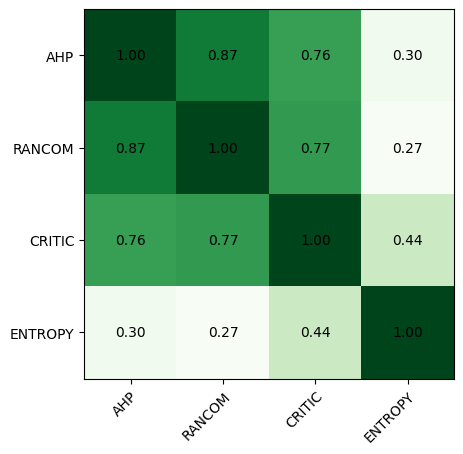

In [118]:
methods = ['AHP', 'RANCOM', 'CRITIC', 'ENTROPY']
n = len(weights_list)
W = np.eye(n)  

for i in range(n):
    for j in range(i + 1, n):
        sim = wsc(weights_list[i], weights_list[j])
        W[i, j] = W[j, i] = sim   

print("Macierz podobieństw WSC:\n", W)

correlation_heatmap(W, labels=methods)


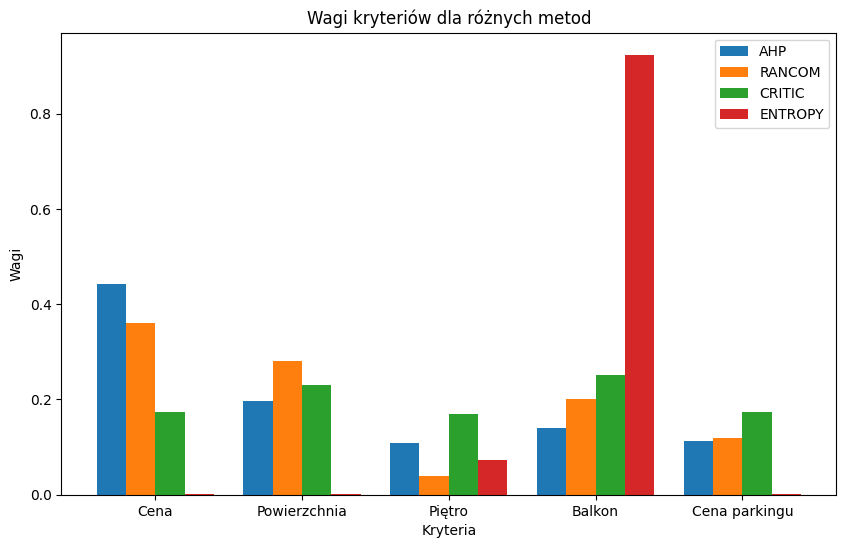

In [ ]:
criteria = ['Cena', 'Powierzchnia', 'Piętro', 'Balkon', 'Cena parkingu']
x = np.arange(len(criteria))
width = 0.2
plt.figure(figsize=(10, 6))
for i in range(len(weights_list)):
    plt.bar(x + i*width, weights_list[i], width=width, label=methods[i])
plt.xticks(x + width * (len(weights_list) - 1) / 2, criteria)
plt.xlabel('Kryteria')
plt.ylabel('Wagi')
plt.title('Wagi kryteriów dla różnych metod')
plt.legend()
plt.show()

## Interpretecja wag 

Wyniki korelacji dla metod subiektywnych AHP i RANCOM uzyskały wysoką zgodność na poziomie 87%. Pomimo róznych podejść obie metody w zblizony sposób oddały hierarchię wazności, co sugeruje względną stabilność dla późniejszych wyników w przypadków wykorzystania jednego z dwóch wektorów. Metoda CRITIC uzyskała względnie zblizony wynik do metod subiektywnych, pomimo bycia metodą obiektywną. Moze to oznaczać, ze preferencje decydenta dość dobrze współgrają z obiektywnymi cechami danych. Metoda ENTROPY przedstawia skrajnie odmienne wyniki od 3 pozostałych metod , nawet od równiez obiektywnej metody CRITIC. Moze to wynikać z tego, ze róznice między konkretnymi alternatywami i ich kryteriami nie są duze co przekłada się na niskią korelację z innymi rankingami, poniewaz metoda ENTROPY premiuje kryteria mocno rózniące się między sobą. Szczególnie widać to na wykresie słupkowym, gdzie ENTROPY ocenia blisko zera kluczowe kryteria dla metod subiektywnych (Cena mieszkania, powierzchnia oraz cena parkingu), a największą wartość przypisuje metrazowi balkonów. Moze to sugerować niską uzyteczność w przedstawionym problemie inwestycyjnym, poniewaz metoda ta praktycznie ignoruje aspekty finansowe, a róznice chociazby w cenie, mimo, ze wzglednie zblizone to jednak zauwazalnie rózne, szczególnie jeśli spojrzy się na skrajne wartości, gdzie róznica między najtanszą, a najdrozszą inwestycją to nawet 120 tyś złotych. 

In [114]:
pref_results = []
rankings = []
for method in [TOPSIS, SPOTIS, VIKOR, COMET, WASPAS]:
    if method == TOPSIS:
        body = method()
        pref = body(D, weights_list[1], types)
        r = rrankdata(pref)
    elif method == SPOTIS:
        body = method(bounds)
        pref = body(D, weights_list[1], types)
        r = rankdata(pref)
    elif method == WASPAS:
        body = method()
        pref = body(D, weights_list[1], types)
        r = rrankdata(pref)
    elif method == COMET:
        cvalues = np.vstack((
        np.min(D, axis=0),
        np.max(D, axis=0))).T
        body = COMET(cvalues, MethodExpert(TOPSIS(), weights_list[1], types))
        pref = body(D)   
        r = rrankdata(pref)     
    elif method == VIKOR:
        body = method()
        pref = body(D, weights_list[1], types)
        r = rankdata(pref)

    pref_results.append(pref)
    rankings.append(r)
    print(f"Ranking {method.__name__}: {r}")



Ranking TOPSIS: [3. 1. 6. 2. 4. 5.]
Ranking SPOTIS: [2. 1. 6. 3. 4. 5.]
Ranking VIKOR: [2. 1. 6. 5. 3. 4.]
Ranking COMET: [3. 1. 6. 2. 5. 4.]
Ranking WASPAS: [1. 2. 4. 3. 6. 5.]


[[3. 1. 6. 2. 4. 5.]
 [2. 1. 6. 3. 4. 5.]
 [2. 1. 6. 5. 3. 4.]
 [3. 1. 6. 2. 5. 4.]
 [1. 2. 4. 3. 6. 5.]]


<Axes: ylabel='Position in ranking'>

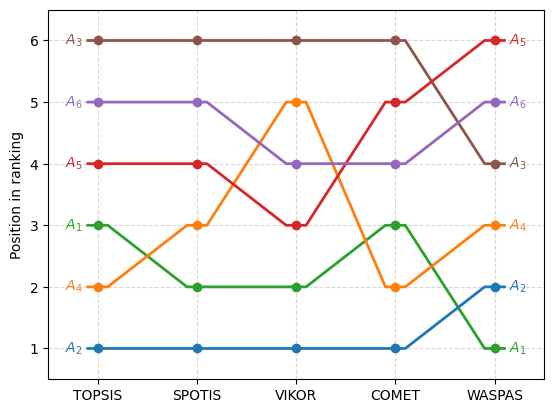

In [115]:
r_flows = np.array(rankings)
print(r_flows)
ranking_flows(rankings, ['TOPSIS', 'SPOTIS', 'VIKOR', 'COMET', 'WASPAS'])


Porównanie TOPSIS vs SPOTIS:
 Skorelowanie Spearmana: 0.9265
 Współczynnik podobieństwa rang (WS): 0.8958

Porównanie TOPSIS vs VIKOR:
 Skorelowanie Spearmana: 0.6571
 Współczynnik podobieństwa rang (WS): 0.7422

Porównanie TOPSIS vs COMET:
 Skorelowanie Spearmana: 0.9592
 Współczynnik podobieństwa rang (WS): 0.9714

Porównanie TOPSIS vs WASPAS:
 Skorelowanie Spearmana: 0.6245
 Współczynnik podobieństwa rang (WS): 0.7063

Porównanie SPOTIS vs VIKOR:
 Skorelowanie Spearmana: 0.8531
 Współczynnik podobieństwa rang (WS): 0.8880

Porównanie SPOTIS vs COMET:
 Skorelowanie Spearmana: 0.8857
 Współczynnik podobieństwa rang (WS): 0.8672

Porównanie SPOTIS vs WASPAS:
 Skorelowanie Spearmana: 0.7796
 Współczynnik podobieństwa rang (WS): 0.7896

Porównanie VIKOR vs COMET:
 Skorelowanie Spearmana: 0.6082
 Współczynnik podobieństwa rang (WS): 0.8307

Porównanie VIKOR vs WASPAS:
 Skorelowanie Spearmana: 0.5429
 Współczynnik podobieństwa rang (WS): 0.6698

Porównanie COMET vs WASPAS:
 Skorelowanie Sp

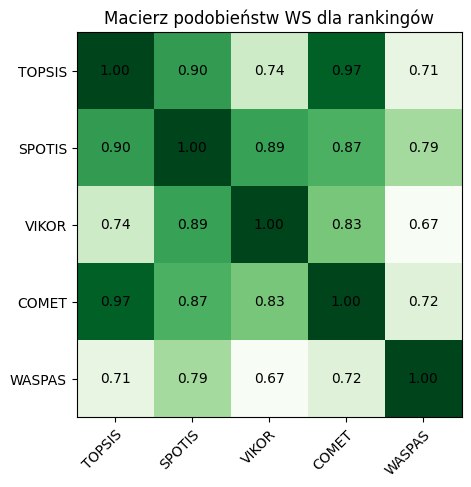

In [123]:
methods = ['TOPSIS', 'SPOTIS', 'VIKOR', 'COMET', 'WASPAS']
n_methods = len(methods)
ws_matrix = np.zeros((n_methods, n_methods))

for i in range(n_methods):
    for j in range(i, n_methods):
        ws = rank_similarity_coef(rankings[i], rankings[j])
        ws_matrix[i, j] = ws
        ws_matrix[j, i] = ws  
        if i < j:
            spearman_corr = weighted_spearman(rankings[i], rankings[j])
            print(f"Porównanie {methods[i]} vs {methods[j]}:")
            print(f" Skorelowanie Spearmana: {spearman_corr:.4f}")
            print(f" Współczynnik podobieństwa rang (WS): {ws:.4f}\n")

plt.figure(figsize=(6, 5))
correlation_heatmap(ws_matrix, labels=methods)
plt.title("Macierz podobieństw WS dla rankingów")
plt.show()

## Interpretacja rankingów

Wyłączając metodę WASPAS wszystkie rankingi dały identyczne skrajne miejsca (A2 = najlepsza, A3 = najgorsza), a nawet WASPAS względnie blisko podał obie te alternatywy plasując A2 jako 2 najlepszą i A3 podając w dolnej połowie rankingu. Największą korelację uzyskano dla metod TOPSIS i COMET, co nie moze zaskakiwać, ze względu na wykorzystanie TOPSIS jako MethodExpert do COMET. Ciekawe natomiast jest wyzsze skorelowanie SPOTIS i TOPSIS, niz SPOTIS i COMET, lecz mimo to sugeruje to wysoką stabilność rankingów. Środkowa część rankingów jest najmniej stabilną częścią. Alternatywy A1, A4, A5 i A6 zmieniają płynnie pozycje między rankingami, co moze oznaczać, ze ich poziom optymalności, jako rozwiązanie problemu jest podobny i cięzko między nimi wskazać wyraźnego faworyta. Metodą najmnniej skorelowaną z pozostałymi jest WASPAS. Moze to wynikać z samej charakterystyki, bowiem metoda ta duzo słabiej ocenia alternatywy, w których poszczególne kryteria są wyraźnie słabsze. Ma to odzwierciedlenie w rankingu, gdzie alternatywy A5 i A6 są ocenione najgorzej, a patrząc na ich kryteria mozna zwrócić uwagę na to, ze są to jedyne 2 opcje bez balkonów. 